# Receptor KD × CytoSignal LR score elastic-net screen

This notebook is a **screening step** before gene-level single-LR regression.

Goal: for each receptor KD target and each CytoSignal radius, fit one high-dimensional model containing all LR scores and all `KD × LR` interaction terms. The output is a ranked list of LR scores whose interaction terms carry the most information.

Important: elastic-net coefficients are shrinkage-biased and do **not** provide ordinary OLS p-values. Treat this notebook as candidate ranking, not final significance testing.

Downstream workflow:

1. Selection of top LR scores per receptor KD.
2. Ordinary single-LR models restricted to the selected LR scores:

$$
Y_g \sim KD_R + LR_j + KD_R \times LR_j
$$

3. Gene-level p-value and FDR estimation in the second-stage notebook.

In [1]:
from __future__ import annotations

import json
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp

import mudata as mu

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import MultiTaskElasticNet

import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)


## 1. Configuration

The perturbation column is selected after inspection of `rna.obs`. Likely columns are detected automatically when possible because receptor-KD annotation names vary across datasets.

In [2]:
INPUT_H5MU = Path('/scratch/luvul_root/luvul0/luvul/all_lanes_merged_with_cytosignal_diffusion_lr.h5mu')
OUTPUT_DIR = Path('/scratch/luvul_root/luvul0/luvul/receptor_cytosignal_lr_elasticnet_screen_results')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RNA_MOD = 'rna'
LR_MOD = 'lr_cytosignal'

# CytoSignal handoff: X is 200 µm; layers store all three radii.
RADIUS_LAYERS = {
    100: 'radius_100um',
    200: 'radius_200um',
    400: 'radius_400um',
}

# Match receptor_interaction_analysis.ipynb when possible: KD/control come from target_call.
# KD: target_call == receptor. Control: target_call == 'Non-Targeting'.
# If your dataset uses a different column, set it manually after metadata inspection.
PERTURBATION_COLUMN = 'target_call'

# If your perturbation annotation contains guide names instead of receptor symbols, provide a CSV mapping here.
# Expected columns can be guide/sgRNA plus target/gene_symbol. Leave as None if obs already contains target symbols.
GUIDE_TO_TARGET_CSV = None

# Control definition. Default is strict: only explicitly non-perturbed / negative-control cells are controls.
# Do not use all other KD cells as controls unless you deliberately set CONTROL_MODE='not_current_target'.
CONTROL_MODE = 'explicit_negative_control'  # options: 'explicit_negative_control', 'not_current_target'
NEGATIVE_CONTROL_COLUMN = None  # usually leave None; PERTURBATION_COLUMN labels are used
NEGATIVE_CONTROL_LABELS = {'Non-Targeting', 'non targeting', 'non-targeting', 'nontargeting', 'non_targeting', 'NTC'}
MISSING_PERTURBATION_LABELS = {'nan', '', 'none', 'na', 'NA', 'NaN', '<NA>'}
EXCLUDE_TARGET_LABELS = {'Unassigned', 'No_CRISPR_data'}
REQUIRE_EXPLICIT_NEGATIVE_CONTROLS = True

# Screening limits. Set TOP_N_RECEPTOR_KDS=None to run all eligible receptor KDs.
MIN_KD_CELLS = 30
MIN_CONTROL_CELLS = 100
TOP_N_RECEPTOR_KDS = None

# Global LR-score feature QC before any model fitting.
# Availability is structural: unavailable LR interactions should not be silently treated as zeros.
LR_MIN_AVAILABLE_EB_FRACTION = 1.0  # use 0.9 if too few LR scores survive
LR_MIN_GLOBAL_NONZERO_FRACTION = 0.005
LR_MIN_GLOBAL_SD = 1e-8
LR_MIN_APPROX_UNIQUE_VALUES = 2  # removes all-constant features, including all-zero
LR_APPROX_UNIQUE_DECIMALS = 8

# LR-score QC inside each KD/control subset.
MIN_LR_NONZERO_FRACTION = 0.005
MIN_LR_SD = 1e-8
MAX_LR_SCORES_PER_MODEL = None  # None keeps all LR scores passing QC; use e.g. 300 for faster trial runs.

# RNA representation for elastic-net screening.
# We rank LR scores by predicting RNA PCs, not every gene, so this is much faster than gene-level regression.
N_RNA_PCS = 30
TOP_VARIABLE_GENES_FOR_PCA = 8000
FORCE_RECOMPUTE_RNA_PCS = False

# Elastic-net settings for screening.
# Fixed-alpha mode is intentional: this notebook ranks candidate LR scores, not final p-values.
# Avoiding cross-validation makes each target/radius model much faster.
ELASTICNET_ALPHA = 0.01
ELASTICNET_L1_RATIO = 0.5
MAX_ITER = 5000
RANDOM_STATE = 20260729

print('Input:', INPUT_H5MU)
print('Output dir:', OUTPUT_DIR)


Input: /scratch/luvul_root/luvul0/luvul/all_lanes_merged_with_cytosignal_diffusion_lr.h5mu
Output dir: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_lr_elasticnet_screen_results


## 2. Load H5MU and inspect metadata

This reads the H5MU into memory. The current main integrated file is about 2.1 GB on disk.

In [3]:
assert INPUT_H5MU.is_file(), INPUT_H5MU
mdata = mu.read_h5mu(INPUT_H5MU)
rna = mdata.mod[RNA_MOD]
lr = mdata.mod[LR_MOD]

print(mdata)
print('RNA:', rna.shape)
print('LR:', lr.shape)
print('LR layers:', list(lr.layers.keys()))
display(lr.var.head())

obs_cols = pd.Series(rna.obs.columns, name='rna_obs_columns')
display(obs_cols.to_frame().head(100))

candidate_patterns = re.compile(r'guide|grna|sgrna|perturb|target|kd|crispr', re.I)
candidate_cols = [c for c in rna.obs.columns if candidate_patterns.search(c)]
print('Likely perturbation columns:')
for c in candidate_cols:
    print('  ', c)
    display(rna.obs[c].astype(str).value_counts().head(20).to_frame('n'))

(OUTPUT_DIR / 'metadata_inspection.json').write_text(json.dumps({
    'input_h5mu': str(INPUT_H5MU),
    'rna_shape': list(rna.shape),
    'lr_shape': list(lr.shape),
    'lr_layers': list(lr.layers.keys()),
    'rna_obs_columns': list(rna.obs.columns),
    'likely_perturbation_columns': candidate_cols,
}, indent=2))


MuData object with n_obs × n_vars = 17043 × 173195
  obs:	'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'log10_nCount_RNA', 'log10_nFeature_RNA', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.2', 'seurat_clusters', 'gex_barcode', 'lane', 'guide_data_present', 'guide_call', 'call_status', 'guides_passing_str', 'guide_umis_passing_str', 'n_guides_passing', 'posterior_top_guide', 'posterior_top_probability', 'top_guide', 'top_guide_umis', 'second_guide_umis', 'total_guide_umis', 'n_guides_nonzero', 'top_fraction', 'top_minus_second', 'atac_barcode', 'atac_barcode_linked', 'global_cell_id', 'raw_cell_barcode', 'orig.ident', 'nCount_peaks', 'nFeature_peaks', 'barcode_raw', 'SPATIAL_1', 'SPATIAL_2', 'target_call', 'signac_call_status', 'top_target', 'top_target_umis', 'second_target_umis', 'total_target_umis', 'signac_top_fraction', 'signac_top_minus_second', 'n_targets_nonzero', 'merged_dataset', 'nucleosome_signal', 'TSS_enrichment', 'ATAC_total_counts', 'ATAC_peaks_detected', 'pass_percent_m

,ligand_name,receptor_name,lr_name,lr_type
interaction_id,,,,
CPI-CC09BCDA08E,EBI3+IL27,IL27RA+IL6ST,EBI3+IL27_IL27RA+IL6ST,diffusion
CPI-CC0C3ECBD1F,EBI3+IL12A,IL6ST+IL12RB2,EBI3+IL12A_IL6ST+IL12RB2,diffusion
CPI-CS008C9D6E5,IL1B,IL1R2+IL1RAP,IL1B_IL1R2+IL1RAP,diffusion
CPI-CS00BF6CD40,IL4,IL13RA1+IL4R,IL4_IL13RA1+IL4R,diffusion
CPI-CS0107C51C6,BMP4,BMPR1B+BMPR2,BMP4_BMPR1B+BMPR2,diffusion


,rna_obs_columns
0,nCount_RNA
1,nFeature_RNA
2,percent.mt
3,log10_nCount_RNA
4,log10_nFeature_RNA
...,...
64,spatial_kmeans
65,EB_manual
66,EB_manual_clustering
67,cell_type


Likely perturbation columns:
   guide_data_present


,n
guide_data_present,
True,15994
False,1049


...

   total_target_umis


,n
total_target_umis,
2.0,1844
1.0,1672
3.0,1647
4.0,1438
5.0,1172
nan,1049
6.0,947
7.0,789
8.0,693


   n_targets_nonzero


,n
n_targets_nonzero,
2.0,4153
3.0,3707
1.0,3082
4.0,2414
5.0,1379
nan,1049
6.0,657
7.0,291
8.0,125


2290

## 3. Helper functions

The key model per receptor KD and radius is:

$$
RNA\ PC_k \sim KD_R + LR_1 + \cdots + LR_p + KD_R LR_1 + \cdots + KD_R LR_p
$$

Each LR score is ranked using:

- `lr_main_l2`: L2 norm of LR main-effect coefficients across RNA PCs.
- `interaction_l2`: L2 norm of `KD × LR` coefficients across RNA PCs. This is the main screen statistic.
- `interaction_nonzero_pc_fraction`: fraction of RNA PCs with nonzero interaction coefficient.

In [4]:
def normalize_token(x):
    if pd.isna(x):
        return ''
    return str(x).strip()


def split_targets(value):
    text = normalize_token(value)
    if text in NEGATIVE_CONTROL_LABELS or text.lower() in {x.lower() for x in NEGATIVE_CONTROL_LABELS}:
        return []
    if text in MISSING_PERTURBATION_LABELS or text.lower() in {x.lower() for x in MISSING_PERTURBATION_LABELS}:
        return []
    if text in EXCLUDE_TARGET_LABELS or text.lower() in {x.lower() for x in EXCLUDE_TARGET_LABELS}:
        return []
    parts = re.split(r'[;,|/\s]+', text)
    blocked = {x.lower() for x in NEGATIVE_CONTROL_LABELS | MISSING_PERTURBATION_LABELS | EXCLUDE_TARGET_LABELS}
    return [p.strip() for p in parts if p.strip() and p.strip().lower() not in blocked]


def choose_perturbation_column(obs, manual_column=None):
    if manual_column is not None:
        assert manual_column in obs.columns, manual_column
        return manual_column
    if 'target_call' in obs.columns:
        return 'target_call'
    candidates = [c for c in obs.columns if re.search(r'target|perturb|guide|grna|sgrna|kd', c, re.I)]
    if not candidates:
        raise ValueError('No perturbation-like column found. Set PERTURBATION_COLUMN manually.')
    # Prefer target_call / target-like columns over raw guide columns.
    candidates = sorted(candidates, key=lambda c: (0 if c == 'target_call' else 1 if re.search(r'target|perturb|kd', c, re.I) else 2, len(c)))
    return candidates[0]


def make_target_sets(obs, perturbation_column):
    raw = obs[perturbation_column].astype(str)
    target_sets = raw.map(split_targets)
    n_targets = target_sets.map(len)
    return target_sets, n_targets



def infer_negative_control_mask(obs, perturbation_column, target_sets, n_targets, control_column=None):
    """Identify true negative/non-perturbed controls before model fitting.

    If a dedicated NEGATIVE_CONTROL_COLUMN is provided, use it. Otherwise, use cells
    whose perturbation annotation resolves to zero experimental targets. This is
    still an explicit control definition from the annotation, not "all cells that
    are not the current KD".
    """
    if control_column is not None:
        assert control_column in obs.columns, control_column
        raw = obs[control_column]
        if pd.api.types.is_bool_dtype(raw):
            mask = raw.fillna(False).astype(bool)
        else:
            text = raw.astype(str).str.strip().str.lower()
            mask = text.isin({v.lower() for v in NEGATIVE_CONTROL_LABELS})
        source = control_column
    else:
        raw = obs[perturbation_column].astype(str).str.strip().str.lower()
        mask = raw.isin({v.lower() for v in NEGATIVE_CONTROL_LABELS})
        source = f'{perturbation_column}:negative_control_labels_only'

    qc = {
        'control_source': source,
        'n_negative_control_cells': int(mask.sum()),
        'fraction_negative_control_cells': float(mask.mean()),
        'n_total_cells_with_lr': int(len(mask)),
        'control_mode': CONTROL_MODE,
    }
    if REQUIRE_EXPLICIT_NEGATIVE_CONTROLS and int(mask.sum()) == 0:
        raise ValueError(
            'No explicit negative/non-perturbed controls were found. Set NEGATIVE_CONTROL_COLUMN, '
            'check CONTROL_LABELS, or deliberately change the control definition.'
        )
    return mask.astype(bool), qc


def to_dense_float32(x):
    if sp.issparse(x):
        x = x.toarray()
    return np.asarray(x, dtype=np.float32)


def matrix_column_stats(x):
    # x is dense cells × features.
    nonzero_fraction = (x != 0).mean(axis=0)
    sd = x.std(axis=0)
    mean = x.mean(axis=0)
    return mean, sd, nonzero_fraction


def compute_or_load_rna_pcs(rna, cell_names, output_dir, n_pcs=30, top_variable_genes=8000, force=False):
    pc_path = output_dir / f'rna_pcs_{n_pcs}pcs_{top_variable_genes}genes.npy'
    cell_path = output_dir / f'rna_pcs_{n_pcs}pcs_cell_names.csv'
    gene_path = output_dir / f'rna_pcs_{n_pcs}pcs_selected_genes.csv'
    if pc_path.exists() and cell_path.exists() and not force:
        saved_cells = pd.read_csv(cell_path)['cell'].astype(str).tolist()
        if saved_cells == list(cell_names):
            pcs = np.load(pc_path)
            print('Loaded cached RNA PCs:', pc_path, pcs.shape)
            return pcs
    print('Computing RNA PCs...')
    X = rna[cell_names, :].X
    if sp.issparse(X):
        gene_mean = np.asarray(X.mean(axis=0)).ravel()
        gene_sq_mean = np.asarray(X.multiply(X).mean(axis=0)).ravel()
        gene_var = gene_sq_mean - gene_mean ** 2
    else:
        gene_var = np.asarray(X.var(axis=0)).ravel()
    top_n = min(top_variable_genes, X.shape[1])
    top_idx = np.argsort(gene_var)[-top_n:]
    X_top = X[:, top_idx]
    svd = TruncatedSVD(n_components=n_pcs, random_state=RANDOM_STATE)
    pcs = svd.fit_transform(X_top).astype(np.float32)
    pcs = StandardScaler().fit_transform(pcs).astype(np.float32)
    np.save(pc_path, pcs)
    pd.DataFrame({'cell': list(cell_names)}).to_csv(cell_path, index=False)
    pd.DataFrame({'gene': rna.var_names[top_idx].astype(str)}).to_csv(gene_path, index=False)
    print('Saved RNA PCs:', pc_path, pcs.shape)
    return pcs


def get_lr_matrix_for_radius(lr, radius_um):
    layer = RADIUS_LAYERS[radius_um]
    if layer in lr.layers:
        return lr.layers[layer]
    if radius_um == 200:
        return lr.X
    raise KeyError(f'Missing LR layer for radius {radius_um}: {layer}')



def coerce_availability_table(lr):
    """Return LR-score availability per interaction from lr.uns, if present."""
    avail = lr.uns.get('interaction_available_by_EB', None)
    if avail is None:
        return None
    if isinstance(avail, pd.DataFrame):
        table = avail.copy()
    else:
        table = pd.DataFrame(avail)
    # Usually rows are EB and columns are interactions. If reversed, transpose.
    lr_names = pd.Index(lr.var_names.astype(str))
    col_overlap = len(set(table.columns.astype(str)) & set(lr_names))
    idx_overlap = len(set(table.index.astype(str)) & set(lr_names))
    if idx_overlap > col_overlap:
        table = table.T
    table.columns = table.columns.astype(str)
    return table


def compute_global_lr_feature_qc(lr_aligned):
    """Compute global LR feature QC and return one row per LR score."""
    availability = coerce_availability_table(lr_aligned)
    var = lr_aligned.var.copy()
    qc = pd.DataFrame({
        'lr_index': np.arange(lr_aligned.n_vars),
        'lr_var_name': lr_aligned.var_names.astype(str),
    })
    for col in ['ligand_name', 'receptor_name', 'lr_name', 'lr_type']:
        if col in var.columns:
            qc[col] = var[col].astype(str).to_numpy()

    if availability is not None:
        aligned_cols = [name for name in qc['lr_var_name'] if name in availability.columns]
        available_fraction = pd.Series(0.0, index=qc['lr_var_name'].astype(str))
        if aligned_cols:
            available_fraction.loc[aligned_cols] = availability[aligned_cols].astype(bool).mean(axis=0).reindex(aligned_cols).astype(float).values
        qc['available_eb_fraction'] = qc['lr_var_name'].map(available_fraction).astype(float)
        qc['has_availability_annotation'] = qc['lr_var_name'].isin(aligned_cols)
    else:
        qc['available_eb_fraction'] = 1.0
        qc['has_availability_annotation'] = False

    # Per-radius numeric QC: constant/all-zero features are not useful for models.
    keep_by_radius = []
    for radius_um in RADIUS_LAYERS:
        X = to_dense_float32(get_lr_matrix_for_radius(lr_aligned, radius_um))
        mean, sd, nonzero = matrix_column_stats(X)
        approx_unique = []
        for j in range(X.shape[1]):
            # Rounded unique count is robust to tiny floating noise; cap at 3 for speed/memory clarity.
            vals = np.unique(np.round(X[:, j], LR_APPROX_UNIQUE_DECIMALS))
            approx_unique.append(min(len(vals), 3))
        qc[f'radius_{radius_um}um_mean'] = mean
        qc[f'radius_{radius_um}um_sd'] = sd
        qc[f'radius_{radius_um}um_nonzero_fraction'] = nonzero
        qc[f'radius_{radius_um}um_approx_unique_values_capped3'] = approx_unique
        keep = (
            (qc['available_eb_fraction'] >= LR_MIN_AVAILABLE_EB_FRACTION)
            & (qc[f'radius_{radius_um}um_nonzero_fraction'] >= LR_MIN_GLOBAL_NONZERO_FRACTION)
            & (qc[f'radius_{radius_um}um_sd'] >= LR_MIN_GLOBAL_SD)
            & (qc[f'radius_{radius_um}um_approx_unique_values_capped3'] >= LR_MIN_APPROX_UNIQUE_VALUES)
        )
        qc[f'pass_global_qc_radius_{radius_um}um'] = keep.to_numpy()
        keep_by_radius.append(keep.to_numpy())
    qc['pass_global_qc_any_radius'] = np.vstack(keep_by_radius).any(axis=0)

    def reason(row):
        if row['available_eb_fraction'] < LR_MIN_AVAILABLE_EB_FRACTION:
            return 'low_structural_availability'
        per_radius_reasons = []
        for radius_um in RADIUS_LAYERS:
            if row[f'pass_global_qc_radius_{radius_um}um']:
                return 'pass_at_least_one_radius'
            bits = []
            if row[f'radius_{radius_um}um_nonzero_fraction'] < LR_MIN_GLOBAL_NONZERO_FRACTION:
                bits.append('low_nonzero_fraction')
            if row[f'radius_{radius_um}um_sd'] < LR_MIN_GLOBAL_SD:
                bits.append('low_or_zero_sd')
            if row[f'radius_{radius_um}um_approx_unique_values_capped3'] < LR_MIN_APPROX_UNIQUE_VALUES:
                bits.append('constant_feature')
            per_radius_reasons.extend(bits)
        if not per_radius_reasons:
            return 'filtered_unknown'
        return '|'.join(sorted(set(per_radius_reasons)))

    qc['global_qc_reason'] = qc.apply(reason, axis=1)
    return qc



def lr_receptor_contains_target(receptor_name, target):
    """Return True when the LR receptor complex contains the current KD target."""
    receptor_text = normalize_token(receptor_name)
    target_text = normalize_token(target)
    if not receptor_text or not target_text:
        return False
    parts = [p.strip().upper() for p in re.split(r'[+;,|/\s]+', receptor_text) if p.strip()]
    return target_text.upper() in parts


def fit_one_receptor_radius_screen(target, radius_um, rna_obs_aligned, lr_aligned, lr_matrix, rna_pcs, target_sets, n_targets, negative_control_mask, global_lr_keep_mask=None):
    has_target = target_sets.map(lambda xs: target in xs).to_numpy()
    if CONTROL_MODE == 'explicit_negative_control':
        is_control = np.asarray(negative_control_mask, dtype=bool)
    elif CONTROL_MODE == 'not_current_target':
        # Less strict exploratory mode: all cells without this target are controls.
        # This is intentionally not the default because other KD cells may be confounded.
        is_control = ~has_target
    else:
        raise ValueError(CONTROL_MODE)
    # A KD cell should never also be treated as a control for the same model.
    is_control = is_control & (~has_target)
    keep = has_target | is_control
    kd = has_target[keep].astype(np.float32)
    n_kd = int(kd.sum())
    n_control = int((1 - kd).sum())
    if n_kd < MIN_KD_CELLS or n_control < MIN_CONTROL_CELLS:
        return None, {'target': target, 'radius_um': radius_um, 'status': 'skipped_low_cell_count', 'n_kd': n_kd, 'n_control': n_control}

    X_lr = to_dense_float32(lr_matrix[keep, :])
    lr_mean, lr_sd, lr_nonzero = matrix_column_stats(X_lr)
    feature_keep = (lr_sd >= MIN_LR_SD) & (lr_nonzero >= MIN_LR_NONZERO_FRACTION)
    if global_lr_keep_mask is not None:
        feature_keep = feature_keep & np.asarray(global_lr_keep_mask, dtype=bool)
    if MAX_LR_SCORES_PER_MODEL is not None and feature_keep.sum() > MAX_LR_SCORES_PER_MODEL:
        candidate_idx = np.where(feature_keep)[0]
        top_idx = candidate_idx[np.argsort(lr_sd[candidate_idx])[-MAX_LR_SCORES_PER_MODEL:]]
        limited = np.zeros_like(feature_keep, dtype=bool)
        limited[top_idx] = True
        feature_keep = limited
    kept_idx = np.where(feature_keep)[0]
    p = len(kept_idx)
    if p == 0:
        return None, {'target': target, 'radius_um': radius_um, 'status': 'skipped_no_variable_lr_scores', 'n_kd': n_kd, 'n_control': n_control}

    X_lr = X_lr[:, kept_idx]
    X_lr_z = StandardScaler().fit_transform(X_lr).astype(np.float32)
    kd_col = kd[:, None]
    X_design = np.concatenate([kd_col, X_lr_z, kd_col * X_lr_z], axis=1).astype(np.float32)
    Y = rna_pcs[keep, :].astype(np.float32)

    model = MultiTaskElasticNet(
        alpha=ELASTICNET_ALPHA,
        l1_ratio=ELASTICNET_L1_RATIO,
        fit_intercept=True,
        max_iter=MAX_ITER,
        random_state=RANDOM_STATE,
        selection='cyclic',
    )
    model.fit(X_design, Y)
    coef = model.coef_  # n_pcs × n_features
    kd_coef = coef[:, 0]
    lr_main = coef[:, 1:1+p]
    lr_inter = coef[:, 1+p:1+2*p]

    lr_var = lr_aligned.var.iloc[kept_idx].copy()
    out = pd.DataFrame({
        'target': target,
        'radius_um': radius_um,
        'lr_index': kept_idx,
        'lr_var_name': lr_aligned.var_names[kept_idx].astype(str),
        'n_cells': len(kd),
        'n_kd': n_kd,
        'n_control': n_control,
        'n_lr_scores_in_model': p,
        'alpha': float(ELASTICNET_ALPHA),
        'l1_ratio': float(ELASTICNET_L1_RATIO),
        'kd_coef_l2_across_pcs': float(np.linalg.norm(kd_coef)),
        'lr_main_l2': np.linalg.norm(lr_main, axis=0),
        'lr_main_max_abs': np.max(np.abs(lr_main), axis=0),
        'lr_main_nonzero_pc_fraction': (np.abs(lr_main) > 1e-12).mean(axis=0),
        'interaction_l2': np.linalg.norm(lr_inter, axis=0),
        'interaction_max_abs': np.max(np.abs(lr_inter), axis=0),
        'interaction_nonzero_pc_fraction': (np.abs(lr_inter) > 1e-12).mean(axis=0),
        'lr_mean': lr_mean[kept_idx],
        'lr_sd': lr_sd[kept_idx],
        'lr_nonzero_fraction': lr_nonzero[kept_idx],
    })
    for col in ['ligand_name', 'receptor_name', 'lr_name', 'lr_type']:
        if col in lr_var.columns:
            out[col] = lr_var[col].astype(str).to_numpy()
    if 'receptor_name' in out.columns:
        out['lr_receptor_contains_kd_target'] = out['receptor_name'].map(
            lambda receptor_name: lr_receptor_contains_target(receptor_name, target)
        )
    else:
        out['lr_receptor_contains_kd_target'] = False
    out['interaction_rank'] = out['interaction_l2'].rank(method='first', ascending=False).astype(int)
    out['main_rank'] = out['lr_main_l2'].rank(method='first', ascending=False).astype(int)
    out = out.sort_values(['interaction_rank', 'main_rank']).reset_index(drop=True)
    qc = {
        'target': target,
        'radius_um': radius_um,
        'status': 'completed',
        'n_kd': n_kd,
        'n_control': n_control,
        'n_lr_scores_passing_qc': p,
        'alpha': float(ELASTICNET_ALPHA),
        'l1_ratio': float(ELASTICNET_L1_RATIO),
        'top_interaction_l2': float(out['interaction_l2'].max()),
    }
    return out, qc


## 4. Align cells, create receptor-KD manifest, and compute RNA PCs

In [5]:
common_cells = rna.obs_names.intersection(lr.obs_names)
print('Common RNA/LR cells:', len(common_cells))
rna_aligned = rna[common_cells, :]
lr_aligned = lr[common_cells, :]

perturb_col = choose_perturbation_column(rna_aligned.obs, PERTURBATION_COLUMN)
print('Using perturbation column:', perturb_col)

target_sets, n_targets = make_target_sets(rna_aligned.obs, perturb_col)
negative_control_mask, negative_control_qc = infer_negative_control_mask(
    rna_aligned.obs,
    perturb_col,
    target_sets,
    n_targets,
    control_column=NEGATIVE_CONTROL_COLUMN,
)
negative_control_qc_table = pd.DataFrame([negative_control_qc])
negative_control_qc_table.to_csv(OUTPUT_DIR / 'negative_control_qc.csv', index=False)
print('Negative-control QC:')
display(negative_control_qc_table)

control_value_counts = (
    rna_aligned.obs.loc[negative_control_mask, perturb_col]
    .astype(str)
    .value_counts()
    .head(50)
    .rename_axis('control_annotation_value')
    .reset_index(name='n_cells')
)
control_value_counts.to_csv(OUTPUT_DIR / 'negative_control_annotation_value_counts.csv', index=False)
display(control_value_counts)

excluded_target_mask = rna_aligned.obs[perturb_col].astype(str).str.strip().str.lower().isin(
    {x.lower() for x in EXCLUDE_TARGET_LABELS}
)
excluded_target_counts = (
    rna_aligned.obs.loc[excluded_target_mask, perturb_col]
    .astype(str)
    .value_counts()
    .rename_axis('excluded_annotation_value')
    .reset_index(name='n_cells')
)
excluded_target_counts.to_csv(OUTPUT_DIR / 'excluded_target_annotation_value_counts.csv', index=False)
print('Excluded target-like annotation values:')
display(excluded_target_counts)

all_targets = sorted({t for xs in target_sets for t in xs if t})

manifest_rows = []
for t in all_targets:
    has_t = target_sets.map(lambda xs: t in xs)
    manifest_rows.append({
        'target': t,
        'n_kd_cells': int(has_t.sum()),
        'n_single_target_cells': int(((has_t) & (n_targets == 1)).sum()),
        'n_multi_target_cells': int(((has_t) & (n_targets > 1)).sum()),
        'n_negative_control_cells_available': int(negative_control_mask.sum()),
    })
target_manifest = pd.DataFrame(manifest_rows).sort_values('n_kd_cells', ascending=False)
target_manifest['is_excluded_target_label'] = target_manifest['target'].astype(str).str.lower().isin(
    {x.lower() for x in EXCLUDE_TARGET_LABELS}
)
target_manifest['eligibility_reason'] = np.select(
    [
        target_manifest['is_excluded_target_label'],
        target_manifest['n_kd_cells'] < MIN_KD_CELLS,
        target_manifest['n_negative_control_cells_available'] < MIN_CONTROL_CELLS,
    ],
    [
        'excluded_non_kd_annotation',
        'too_few_kd_cells',
        'too_few_negative_control_cells',
    ],
    default='eligible',
)
target_manifest['eligible_by_cell_count'] = target_manifest['eligibility_reason'].eq('eligible')
target_manifest.to_csv(OUTPUT_DIR / 'receptor_kd_target_manifest.csv', index=False)
display(target_manifest.head(50))

eligible_targets = target_manifest.loc[target_manifest['eligible_by_cell_count'], 'target'].tolist()
if TOP_N_RECEPTOR_KDS is not None:
    eligible_targets = eligible_targets[:TOP_N_RECEPTOR_KDS]
print('Targets selected for elastic-net screen:', len(eligible_targets))
print(eligible_targets[:30])

global_lr_feature_qc = compute_global_lr_feature_qc(lr_aligned)
global_lr_feature_qc.to_csv(OUTPUT_DIR / 'lr_score_global_feature_qc.csv', index=False)
print('LR scores passing global QC by radius:')
for radius_um in RADIUS_LAYERS:
    col = f'pass_global_qc_radius_{radius_um}um'
    print(f'  {radius_um} µm:', int(global_lr_feature_qc[col].sum()), '/', len(global_lr_feature_qc))
display(global_lr_feature_qc['global_qc_reason'].value_counts().to_frame('n'))
display(global_lr_feature_qc.head(20))

rna_pcs = compute_or_load_rna_pcs(
    rna_aligned,
    common_cells,
    OUTPUT_DIR,
    n_pcs=N_RNA_PCS,
    top_variable_genes=TOP_VARIABLE_GENES_FOR_PCA,
    force=FORCE_RECOMPUTE_RNA_PCS,
)
print('RNA PCs:', rna_pcs.shape)


Common RNA/LR cells: 17041
Using perturbation column: target_call
Negative-control QC:


,control_source,n_negative_control_cells,fraction_negative_control_cells,n_total_cells_with_lr,control_mode
0,target_call:negative_control_labels_only,581,0.034094,17041,explicit_negative_control


,control_annotation_value,n_cells
0,Non-Targeting,581


Excluded target-like annotation values:


,excluded_annotation_value,n_cells
0,Unassigned,4261
1,No_CRISPR_data,1049


,target,n_kd_cells,n_single_target_cells,n_multi_target_cells,n_negative_control_cells_available,is_excluded_target_label,eligibility_reason,eligible_by_cell_count
0,ACVR2B,1636,1636,0,581,False,eligible,True
21,SEMA6D,867,867,0,581,False,eligible,True
7,EPHA7,677,677,0,581,False,eligible,True
22,VEGFB,646,646,0,581,False,eligible,True
3,BMP5,566,566,0,581,False,eligible,True
18,PDGFRA,555,555,0,581,False,eligible,True
4,BMP7,544,544,0,581,False,eligible,True
14,NECTIN3,514,514,0,581,False,eligible,True
6,EFNA3,491,491,0,581,False,eligible,True
19,PLXNA2,486,486,0,581,False,eligible,True


Targets selected for elastic-net screen: 25
['ACVR2B', 'SEMA6D', 'EPHA7', 'VEGFB', 'BMP5', 'PDGFRA', 'BMP7', 'NECTIN3', 'EFNA3', 'PLXNA2', 'RSPO3', 'NRP1', 'NECTIN2', 'WNT5A', 'PDGFC', 'DLL3', 'FZD3', 'ALB', 'WNT1', 'B2M', 'FLT1', 'NOTCH1', 'JAG1', 'LGR4', 'FCGRT']
LR scores passing global QC by radius:
  100 µm: 438 / 471
  200 µm: 463 / 471
  400 µm: 467 / 471


,n
global_qc_reason,
pass_at_least_one_radius,467
constant_feature|low_nonzero_fraction|low_or_zero_sd,4


,lr_index,lr_var_name,ligand_name,receptor_name,lr_name,lr_type,available_eb_fraction,has_availability_annotation,radius_100um_mean,radius_100um_sd,radius_100um_nonzero_fraction,radius_100um_approx_unique_values_capped3,pass_global_qc_radius_100um,radius_200um_mean,radius_200um_sd,radius_200um_nonzero_fraction,radius_200um_approx_unique_values_capped3,pass_global_qc_radius_200um,radius_400um_mean,radius_400um_sd,radius_400um_nonzero_fraction,radius_400um_approx_unique_values_capped3,pass_global_qc_radius_400um,pass_global_qc_any_radius,global_qc_reason
0,0,CPI-CC09BCDA08E,EBI3+IL27,IL27RA+IL6ST,EBI3+IL27_IL27RA+IL6ST,diffusion,1.0,True,0.000402,0.003686,0.113960,3,True,0.000492,0.002391,0.264538,3,True,0.000538,0.001648,0.410657,3,True,True,pass_at_least_one_radius
1,1,CPI-CC0C3ECBD1F,EBI3+IL12A,IL6ST+IL12RB2,EBI3+IL12A_IL6ST+IL12RB2,diffusion,1.0,True,0.000989,0.006178,0.250983,3,True,0.001069,0.003462,0.513702,3,True,0.001028,0.001808,0.696145,3,True,True,pass_at_least_one_radius
2,2,CPI-CS008C9D6E5,IL1B,IL1R2+IL1RAP,IL1B_IL1R2+IL1RAP,diffusion,1.0,True,0.000026,0.000508,0.048354,3,True,0.000038,0.000335,0.138079,3,True,0.000049,0.000194,0.327035,3,True,True,pass_at_least_one_radius
3,3,CPI-CS00BF6CD40,IL4,IL13RA1+IL4R,IL4_IL13RA1+IL4R,diffusion,1.0,True,0.000079,0.001574,0.046652,3,True,0.000091,0.000767,0.123936,3,True,0.000090,0.000382,0.249575,3,True,True,pass_at_least_one_radius
4,4,CPI-CS0107C51C6,BMP4,BMPR1B+BMPR2,BMP4_BMPR1B+BMPR2,diffusion,1.0,True,0.173507,0.201074,0.992254,3,True,0.204462,0.155615,0.998592,3,True,0.218090,0.109068,0.999061,3,True,True,pass_at_least_one_radius
5,5,CPI-CS012D15A88,BMP4,BMPR1A+ACVR2A,BMP4_BMPR1A+ACVR2A,diffusion,1.0,True,0.211865,0.232731,0.992254,3,True,0.251980,0.184651,0.998592,3,True,0.271130,0.133537,0.999061,3,True,True,pass_at_least_one_radius
6,6,CPI-CS01319F57A,BMP8A,BMPR1B+ACVR2A,BMP8A_BMPR1B+ACVR2A,diffusion,1.0,True,0.002195,0.013801,0.197817,3,True,0.002634,0.009234,0.406138,3,True,0.002758,0.005653,0.580541,3,True,True,pass_at_least_one_radius
7,7,CPI-CS0152E177A,VWF,GP1BA+GP1BB,VWF_GP1BA+GP1BB,diffusion,1.0,True,0.000996,0.005038,0.449680,3,True,0.001153,0.003043,0.852063,3,True,0.001242,0.001703,0.984391,3,True,True,pass_at_least_one_radius
8,8,CPI-CS017A50010,BMP8A,BMPR1A+ACVR2B,BMP8A_BMPR1A+ACVR2B,diffusion,1.0,True,0.006067,0.038401,0.198580,3,True,0.007333,0.028993,0.406960,3,True,0.007545,0.017975,0.580658,3,True,True,pass_at_least_one_radius
9,9,CPI-CS01A4D7E2F,BMP5,BMPR1B+ACVR2A,BMP5_BMPR1B+ACVR2A,diffusion,1.0,True,0.505370,0.359049,0.997653,3,True,0.558741,0.278124,0.999941,3,True,0.577909,0.205629,0.999941,3,True,True,pass_at_least_one_radius


Loaded cached RNA PCs: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_lr_elasticnet_screen_results/rna_pcs_30pcs_8000genes.npy (17041, 30)
RNA PCs: (17041, 30)


## 4b. LR score feature-QC distributions

LR-score usability is assessed before elastic-net fitting. This section reports structural EB availability, nonzero fractions, score SDs, approximate constant/all-zero features, and pass/fail counts per radius.

These diagnostics support evaluation of whether `LR_MIN_AVAILABLE_EB_FRACTION = 1.0` is an appropriate threshold.

,radius_um,n_lr_scores_total,n_pass_global_qc,fraction_pass_global_qc,n_available_by_threshold,n_nonzero_by_threshold,n_variable_by_sd_threshold,n_nonconstant_by_unique_threshold,median_nonzero_fraction,median_sd,max_sd
0,100,471,438,0.929936,471,438,457,457,0.311367,0.013252,1.177777
1,200,471,463,0.983015,471,463,465,466,0.644270,0.008892,0.956423
2,400,471,467,0.991507,471,467,467,467,0.810927,0.005331,0.720352


,global_qc_reason,n_lr_scores
0,pass_at_least_one_radius,467
1,constant_feature|low_nonzero_fraction|low_or_z...,4


,lr_index,lr_var_name,available_eb_fraction,global_qc_reason,pass_global_qc,nonzero_fraction,score_sd,approx_unique_values_capped3,radius_um
413,413,CPI-SS0D5E30C6C,1.0,pass_at_least_one_radius,True,0.997594,1.177777,3,100
26,26,CPI-CS046BCFC6F,1.0,pass_at_least_one_radius,True,0.998944,0.791292,3,100
152,152,CPI-SS00F4DDF4B,1.0,pass_at_least_one_radius,True,0.999061,0.647126,3,100
91,91,CPI-CS0CA393CC5,1.0,pass_at_least_one_radius,True,0.998944,0.612909,3,100
27,27,CPI-CS047EE9E03,1.0,pass_at_least_one_radius,True,0.998944,0.609229,3,100
39,39,CPI-CS05EAF93CC,1.0,pass_at_least_one_radius,True,0.999178,0.559677,3,100
17,17,CPI-CS02C93975C,1.0,pass_at_least_one_radius,True,0.998944,0.527051,3,100
142,142,CPI-SS006C6537E,1.0,pass_at_least_one_radius,True,0.998122,0.511202,3,100
103,103,CPI-CS0E1BF543E,1.0,pass_at_least_one_radius,True,0.998944,0.503090,3,100
104,104,CPI-CS0E4E75E3B,1.0,pass_at_least_one_radius,True,0.991961,0.493485,3,100


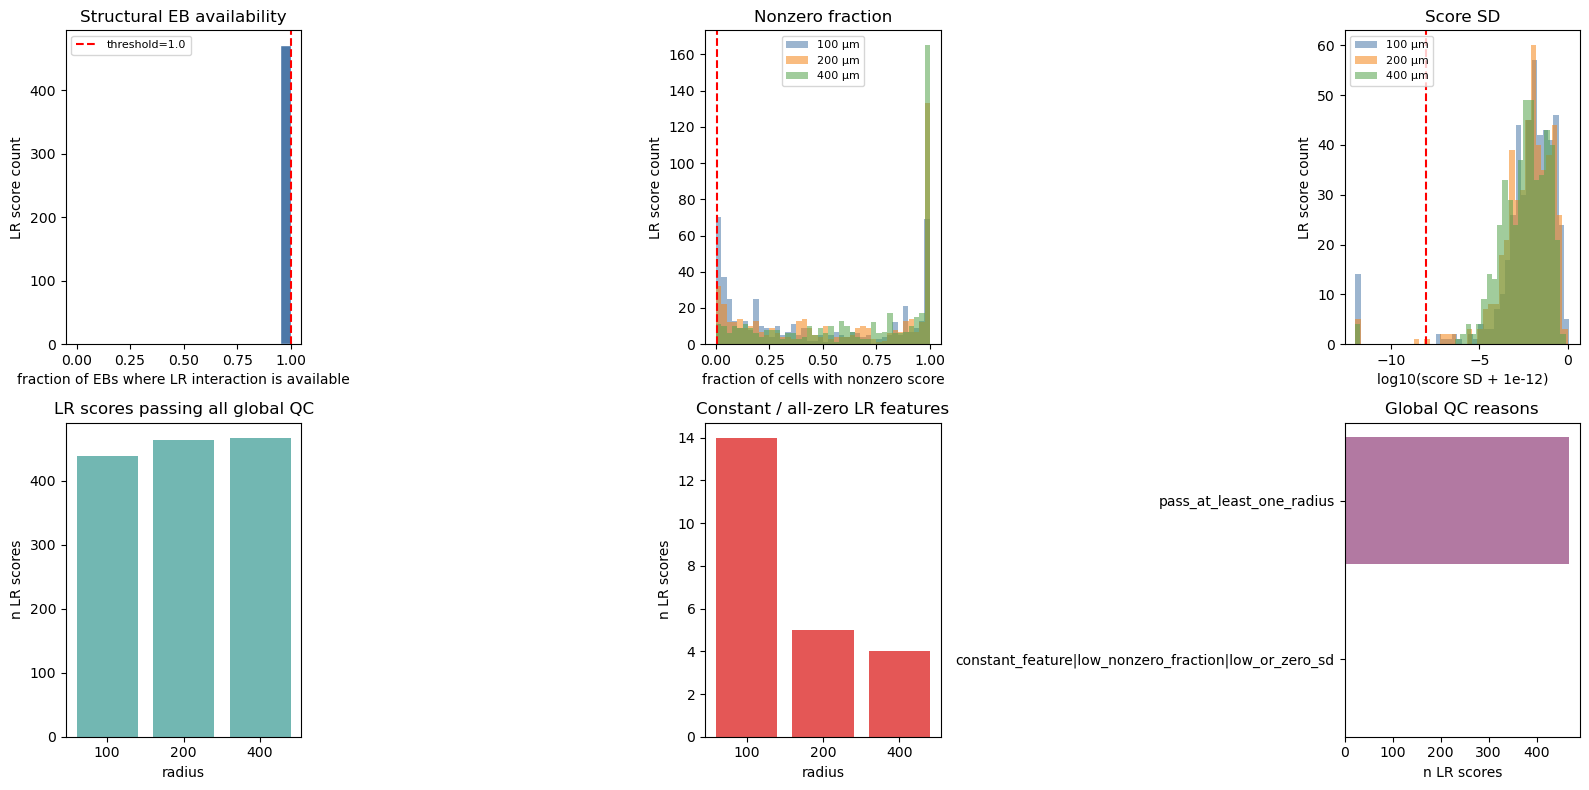

In [6]:
# LR score feature-QC distribution plots and summary tables.
assert 'global_lr_feature_qc' in globals(), 'Run the previous cell first.'

qc = global_lr_feature_qc.copy()
radius_rows = []
for radius_um in RADIUS_LAYERS:
    pass_col = f'pass_global_qc_radius_{radius_um}um'
    sd_col = f'radius_{radius_um}um_sd'
    nz_col = f'radius_{radius_um}um_nonzero_fraction'
    uniq_col = f'radius_{radius_um}um_approx_unique_values_capped3'
    radius_rows.append({
        'radius_um': radius_um,
        'n_lr_scores_total': len(qc),
        'n_pass_global_qc': int(qc[pass_col].sum()),
        'fraction_pass_global_qc': float(qc[pass_col].mean()),
        'n_available_by_threshold': int((qc['available_eb_fraction'] >= LR_MIN_AVAILABLE_EB_FRACTION).sum()),
        'n_nonzero_by_threshold': int((qc[nz_col] >= LR_MIN_GLOBAL_NONZERO_FRACTION).sum()),
        'n_variable_by_sd_threshold': int((qc[sd_col] >= LR_MIN_GLOBAL_SD).sum()),
        'n_nonconstant_by_unique_threshold': int((qc[uniq_col] >= LR_MIN_APPROX_UNIQUE_VALUES).sum()),
        'median_nonzero_fraction': float(qc[nz_col].median()),
        'median_sd': float(qc[sd_col].median()),
        'max_sd': float(qc[sd_col].max()),
    })
lr_qc_radius_summary = pd.DataFrame(radius_rows)
lr_qc_radius_summary.to_csv(OUTPUT_DIR / 'lr_score_global_feature_qc_radius_summary.csv', index=False)
display(lr_qc_radius_summary)

reason_summary = (
    qc['global_qc_reason']
    .value_counts(dropna=False)
    .rename_axis('global_qc_reason')
    .reset_index(name='n_lr_scores')
)
reason_summary.to_csv(OUTPUT_DIR / 'lr_score_global_feature_qc_reason_summary.csv', index=False)
display(reason_summary)

# Long-format table for plotting distributions by radius.
plot_rows = []
for radius_um in RADIUS_LAYERS:
    sub = qc[[
        'lr_index', 'lr_var_name', 'available_eb_fraction', 'global_qc_reason',
        f'pass_global_qc_radius_{radius_um}um',
        f'radius_{radius_um}um_nonzero_fraction',
        f'radius_{radius_um}um_sd',
        f'radius_{radius_um}um_approx_unique_values_capped3',
    ]].copy()
    sub['radius_um'] = radius_um
    sub = sub.rename(columns={
        f'pass_global_qc_radius_{radius_um}um': 'pass_global_qc',
        f'radius_{radius_um}um_nonzero_fraction': 'nonzero_fraction',
        f'radius_{radius_um}um_sd': 'score_sd',
        f'radius_{radius_um}um_approx_unique_values_capped3': 'approx_unique_values_capped3',
    })
    plot_rows.append(sub)
lr_qc_long = pd.concat(plot_rows, ignore_index=True)
lr_qc_long.to_csv(OUTPUT_DIR / 'lr_score_global_feature_qc_long_by_radius.csv', index=False)
display(lr_qc_long.sort_values(['radius_um', 'score_sd'], ascending=[True, False]).head(30))

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

axes[0, 0].hist(qc['available_eb_fraction'], bins=np.linspace(0, 1, 21), color='#4C78A8', edgecolor='white')
axes[0, 0].axvline(LR_MIN_AVAILABLE_EB_FRACTION, color='red', linestyle='--', label=f'threshold={LR_MIN_AVAILABLE_EB_FRACTION}')
axes[0, 0].set_title('Structural EB availability')
axes[0, 0].set_xlabel('fraction of EBs where LR interaction is available')
axes[0, 0].set_ylabel('LR score count')
axes[0, 0].legend(fontsize=8)

for radius_um, color in zip(RADIUS_LAYERS, ['#4C78A8', '#F58518', '#54A24B']):
    nz = qc[f'radius_{radius_um}um_nonzero_fraction']
    axes[0, 1].hist(nz, bins=40, alpha=0.55, label=f'{radius_um} µm', color=color)
axes[0, 1].axvline(LR_MIN_GLOBAL_NONZERO_FRACTION, color='red', linestyle='--')
axes[0, 1].set_title('Nonzero fraction')
axes[0, 1].set_xlabel('fraction of cells with nonzero score')
axes[0, 1].set_ylabel('LR score count')
axes[0, 1].legend(fontsize=8)

for radius_um, color in zip(RADIUS_LAYERS, ['#4C78A8', '#F58518', '#54A24B']):
    sd = qc[f'radius_{radius_um}um_sd']
    axes[0, 2].hist(np.log10(sd + 1e-12), bins=40, alpha=0.55, label=f'{radius_um} µm', color=color)
axes[0, 2].axvline(np.log10(LR_MIN_GLOBAL_SD + 1e-12), color='red', linestyle='--')
axes[0, 2].set_title('Score SD')
axes[0, 2].set_xlabel('log10(score SD + 1e-12)')
axes[0, 2].set_ylabel('LR score count')
axes[0, 2].legend(fontsize=8)

pass_counts = lr_qc_radius_summary[['radius_um', 'n_pass_global_qc']].copy()
axes[1, 0].bar(pass_counts['radius_um'].astype(str), pass_counts['n_pass_global_qc'], color='#72B7B2')
axes[1, 0].set_title('LR scores passing all global QC')
axes[1, 0].set_xlabel('radius')
axes[1, 0].set_ylabel('n LR scores')

const_rows = []
for radius_um in RADIUS_LAYERS:
    uniq = qc[f'radius_{radius_um}um_approx_unique_values_capped3']
    const_rows.append({'radius_um': str(radius_um), 'constant_or_all_zero': int((uniq < LR_MIN_APPROX_UNIQUE_VALUES).sum())})
const_df = pd.DataFrame(const_rows)
axes[1, 1].bar(const_df['radius_um'], const_df['constant_or_all_zero'], color='#E45756')
axes[1, 1].set_title('Constant / all-zero LR features')
axes[1, 1].set_xlabel('radius')
axes[1, 1].set_ylabel('n LR scores')

top_reason = reason_summary.head(10).iloc[::-1]
axes[1, 2].barh(top_reason['global_qc_reason'], top_reason['n_lr_scores'], color='#B279A2')
axes[1, 2].set_title('Global QC reasons')
axes[1, 2].set_xlabel('n LR scores')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'lr_score_global_feature_qc_distributions.png', dpi=200, bbox_inches='tight')
plt.show()


## 5. Run elastic-net LR screen

The screen is resumable. An existing `target_radius_lr_elasticnet_screen.csv` is loaded automatically; removal of that file triggers recomputation.

In [7]:
all_rankings = []
qc_rows = []

for target in eligible_targets:
    safe_target = re.sub(r'[^A-Za-z0-9_.-]+', '_', target)
    for radius_um in RADIUS_LAYERS:
        out_path = OUTPUT_DIR / f'{safe_target}_radius{radius_um}um_lr_elasticnet_screen.csv'
        qc_path = OUTPUT_DIR / f'{safe_target}_radius{radius_um}um_lr_elasticnet_screen_qc.json'
        if out_path.exists() and qc_path.exists():
            print('Loading cached screen:', out_path.name)
            ranking = pd.read_csv(out_path)
            qc = json.loads(qc_path.read_text())
        else:
            print(f'Fitting elastic-net screen: target={target}, radius={radius_um} µm')
            lr_matrix = get_lr_matrix_for_radius(lr_aligned, radius_um)
            global_keep = global_lr_feature_qc[f'pass_global_qc_radius_{radius_um}um'].to_numpy()
            ranking, qc = fit_one_receptor_radius_screen(
                target=target,
                radius_um=radius_um,
                rna_obs_aligned=rna_aligned.obs,
                lr_aligned=lr_aligned,
                lr_matrix=lr_matrix,
                rna_pcs=rna_pcs,
                target_sets=target_sets,
                n_targets=n_targets,
                negative_control_mask=negative_control_mask,
                global_lr_keep_mask=global_keep,
            )
            if ranking is not None:
                ranking.to_csv(out_path, index=False)
            qc_path.write_text(json.dumps(qc, indent=2))
        qc_rows.append(qc)
        if ranking is not None:
            all_rankings.append(ranking)

screen_qc = pd.DataFrame(qc_rows)
screen_qc.to_csv(OUTPUT_DIR / 'elasticnet_screen_qc.csv', index=False)
display(screen_qc)

if all_rankings:
    lr_screen_long = pd.concat(all_rankings, ignore_index=True)
else:
    lr_screen_long = pd.DataFrame()
lr_screen_long.to_csv(OUTPUT_DIR / 'lr_elasticnet_screen_long.csv', index=False)
print('Screen rows:', lr_screen_long.shape)
display(lr_screen_long.head(20))


Fitting elastic-net screen: target=ACVR2B, radius=100 µm
Fitting elastic-net screen: target=ACVR2B, radius=200 µm
Fitting elastic-net screen: target=ACVR2B, radius=400 µm
Fitting elastic-net screen: target=SEMA6D, radius=100 µm
Fitting elastic-net screen: target=SEMA6D, radius=200 µm
Fitting elastic-net screen: target=SEMA6D, radius=400 µm
Fitting elastic-net screen: target=EPHA7, radius=100 µm
Fitting elastic-net screen: target=EPHA7, radius=200 µm
Fitting elastic-net screen: target=EPHA7, radius=400 µm
Fitting elastic-net screen: target=VEGFB, radius=100 µm
Fitting elastic-net screen: target=VEGFB, radius=200 µm
Fitting elastic-net screen: target=VEGFB, radius=400 µm
Fitting elastic-net screen: target=BMP5, radius=100 µm
Fitting elastic-net screen: target=BMP5, radius=200 µm
Fitting elastic-net screen: target=BMP5, radius=400 µm
Fitting elastic-net screen: target=PDGFRA, radius=100 µm
Fitting elastic-net screen: target=PDGFRA, radius=200 µm
Fitting elastic-net screen: target=PDGFRA, 

,target,radius_um,status,n_kd,n_control,n_lr_scores_passing_qc,alpha,l1_ratio,top_interaction_l2
0,ACVR2B,100,completed,1636,581,433,0.01,0.5,0.497519
1,ACVR2B,200,completed,1636,581,460,0.01,0.5,0.427078
2,ACVR2B,400,completed,1636,581,467,0.01,0.5,0.423393
3,SEMA6D,100,completed,867,581,433,0.01,0.5,0.538498
4,SEMA6D,200,completed,867,581,459,0.01,0.5,0.943315
...,...,...,...,...,...,...,...,...,...
70,LGR4,200,completed,132,581,459,0.01,0.5,0.697210
71,LGR4,400,completed,132,581,466,0.01,0.5,0.686258
72,FCGRT,100,completed,109,581,436,0.01,0.5,0.797435
73,FCGRT,200,completed,109,581,458,0.01,0.5,0.751576


Screen rows: (33925, 26)


,target,radius_um,lr_index,lr_var_name,n_cells,n_kd,n_control,n_lr_scores_in_model,alpha,l1_ratio,kd_coef_l2_across_pcs,lr_main_l2,lr_main_max_abs,lr_main_nonzero_pc_fraction,interaction_l2,interaction_max_abs,interaction_nonzero_pc_fraction,lr_mean,lr_sd,lr_nonzero_fraction,ligand_name,receptor_name,lr_name,lr_type,interaction_rank,main_rank
0,ACVR2B,100,463,CPI-SS0FAE75A75,2217,1636,581,433,0.01,0.5,0.402541,0.497427,0.247930,1.0,0.497519,0.263035,1.0,1.191534e-05,0.000283,0.012179,RLN1,RXFP1,RLN1_RXFP1,diffusion,1,1
1,ACVR2B,100,225,CPI-SS0445D021B,2217,1636,581,433,0.01,0.5,0.402541,0.437035,0.235006,1.0,0.473360,0.248885,1.0,9.946526e-05,0.001254,0.054578,PYY,NPY5R,PYY_NPY5R,diffusion,2,2
2,ACVR2B,100,127,CPI-SC08968AFE6,2217,1636,581,433,0.01,0.5,0.402541,0.302269,0.111198,1.0,0.421249,0.190400,1.0,1.038730e-01,0.167942,0.911592,MSTN,TGFBR1+ACVR2B,MSTN_TGFBR1+ACVR2B,diffusion,3,20
3,ACVR2B,100,108,CPI-CS0E997FABD,2217,1636,581,433,0.01,0.5,0.402541,0.250682,0.097656,1.0,0.386162,0.156705,1.0,7.615093e-02,0.100954,0.989175,BMP4,BMPR1B+ACVR2B,BMP4_BMPR1B+ACVR2B,diffusion,4,61
4,ACVR2B,100,311,CPI-SS084816B12,2217,1636,581,433,0.01,0.5,0.402541,0.339683,0.179060,1.0,0.369520,0.188494,1.0,3.468964e-08,0.000001,0.005413,HCRT,HCRTR1,HCRT_HCRTR1,diffusion,5,12
5,ACVR2B,100,68,CPI-CS0A6AB5149,2217,1636,581,433,0.01,0.5,0.402541,0.410447,0.188114,1.0,0.369091,0.138328,1.0,2.796767e-06,0.000089,0.013983,IL36B,IL1RL2+IL1RAP,IL36B_IL1RL2+IL1RAP,diffusion,6,4
6,ACVR2B,100,213,CPI-SS03DA2A820,2217,1636,581,433,0.01,0.5,0.402541,0.296671,0.112668,1.0,0.362147,0.134799,1.0,6.082826e-03,0.027786,0.372124,FGF2,CD44,FGF2_CD44,diffusion,7,25
7,ACVR2B,100,434,CPI-SS0E4DE8215,2217,1636,581,433,0.01,0.5,0.402541,0.163573,0.053371,1.0,0.355955,0.130464,1.0,1.146459e-04,0.002425,0.043302,WNT2,FZD1,WNT2_FZD1,diffusion,8,287
8,ACVR2B,100,313,CPI-SS0859C173B,2217,1636,581,433,0.01,0.5,0.402541,0.409572,0.239830,1.0,0.353744,0.193150,1.0,2.659478e-05,0.000555,0.016689,TNFSF14,LTBR,TNFSF14_LTBR,diffusion,9,5
9,ACVR2B,100,250,CPI-SS0577408A3,2217,1636,581,433,0.01,0.5,0.402541,0.147913,0.058626,1.0,0.352584,0.141039,1.0,1.774027e-04,0.002896,0.074876,CGA,FSHR,CGA_FSHR,diffusion,10,316


## 6. Summarize top LR scores

`interaction_l2` is the main ranking metric: larger values mean the `KD × LR` terms explain more RNA-PC variation after elastic-net shrinkage.

In [8]:
if lr_screen_long.empty:
    print('No completed screens yet.')
else:
    top_per_target_radius = (
        lr_screen_long.sort_values(['target', 'radius_um', 'interaction_rank'])
        .groupby(['target', 'radius_um'], as_index=False)
        .head(25)
        .reset_index(drop=True)
    )
    top_per_target_radius.to_csv(OUTPUT_DIR / 'top25_lr_scores_per_target_radius.csv', index=False)

    summary_cols = ['target', 'radius_um', 'lr_var_name', 'interaction_l2', 'interaction_max_abs', 'interaction_nonzero_pc_fraction', 'lr_main_l2', 'lr_sd', 'lr_nonzero_fraction']
    for c in ['ligand_name', 'receptor_name', 'lr_name', 'lr_type']:
        if c in top_per_target_radius.columns:
            summary_cols.append(c)
    display(top_per_target_radius[summary_cols].head(80))

    lr_global_summary = (
        lr_screen_long.groupby(['lr_var_name'], as_index=False)
        .agg(
            n_target_radius_models=('interaction_l2', 'size'),
            max_interaction_l2=('interaction_l2', 'max'),
            median_interaction_l2=('interaction_l2', 'median'),
            max_main_l2=('lr_main_l2', 'max'),
            median_lr_sd=('lr_sd', 'median'),
            median_lr_nonzero_fraction=('lr_nonzero_fraction', 'median'),
        )
        .sort_values('max_interaction_l2', ascending=False)
    )
    lr_global_summary.to_csv(OUTPUT_DIR / 'lr_score_global_elasticnet_importance_summary.csv', index=False)
    display(lr_global_summary.head(50))


,target,radius_um,lr_var_name,interaction_l2,interaction_max_abs,interaction_nonzero_pc_fraction,lr_main_l2,lr_sd,lr_nonzero_fraction,ligand_name,receptor_name,lr_name,lr_type
0,ACVR2B,100,CPI-SS0FAE75A75,0.497519,0.263035,1.0,0.497427,0.000283,0.012179,RLN1,RXFP1,RLN1_RXFP1,diffusion
1,ACVR2B,100,CPI-SS0445D021B,0.473360,0.248885,1.0,0.437035,0.001254,0.054578,PYY,NPY5R,PYY_NPY5R,diffusion
2,ACVR2B,100,CPI-SC08968AFE6,0.421249,0.190400,1.0,0.302269,0.167942,0.911592,MSTN,TGFBR1+ACVR2B,MSTN_TGFBR1+ACVR2B,diffusion
3,ACVR2B,100,CPI-CS0E997FABD,0.386162,0.156705,1.0,0.250682,0.100954,0.989175,BMP4,BMPR1B+ACVR2B,BMP4_BMPR1B+ACVR2B,diffusion
4,ACVR2B,100,CPI-SS084816B12,0.369520,0.188494,1.0,0.339683,0.000001,0.005413,HCRT,HCRTR1,HCRT_HCRTR1,diffusion
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,ALB,100,CPI-SS09F973C1A,0.630709,0.229790,1.0,0.332781,0.016510,0.861179,EFNA4,EPHA2,EFNA4_EPHA2,diffusion
76,ALB,100,CPI-SS08B85996F,0.628576,0.349456,1.0,0.340471,0.007103,0.239558,TTR,NGFR,TTR_NGFR,diffusion
77,ALB,100,CPI-SS03EACE0E0,0.602672,0.261213,1.0,0.284203,0.000765,0.148649,MST1,MST1R,MST1_MST1R,diffusion
78,ALB,100,CPI-SS06E42DB13,0.600879,0.270470,1.0,0.361649,0.002079,0.049140,ADIPOQ,CLEC2D,ADIPOQ_CLEC2D,diffusion


,lr_var_name,n_target_radius_models,max_interaction_l2,median_interaction_l2,max_main_l2,median_lr_sd,median_lr_nonzero_fraction
221,CPI-SS04297753E,75,1.184046,0.358267,1.188799,9.356972e-05,0.040115
325,CPI-SS09185EA8F,50,1.060897,0.309008,0.457820,1.066768e-05,0.038433
293,CPI-SS07A0F4D73,75,0.969065,0.369343,0.473343,1.514632e-02,0.371951
343,CPI-SS0A021DB6E,50,0.943315,0.250987,0.388041,7.791358e-07,0.049459
237,CPI-SS04C396C5D,75,0.924278,0.380092,0.536226,4.606262e-03,0.412530
418,CPI-SS0DA291AD9,75,0.872073,0.275437,0.480453,3.113440e-05,0.046575
459,CPI-SS0FAE75A75,75,0.870492,0.319717,0.784977,1.472820e-04,0.046512
268,CPI-SS062DED513,75,0.831090,0.304239,0.563929,7.170182e-04,0.193878
191,CPI-SS030EDC420,75,0.824812,0.316983,0.443486,1.267975e-04,0.082310
318,CPI-SS08A819670,75,0.814578,0.320605,0.641659,1.391209e-03,0.136007


## 7. QC plots

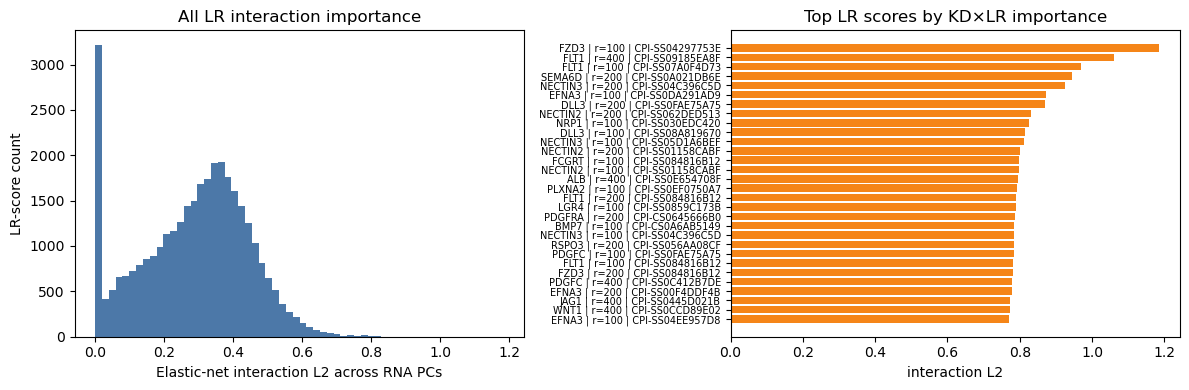

,target,radius_um,n_lr_scores,top_interaction_l2,median_interaction_l2,n_nonzero_interaction_lr_scores
30,FZD3,100,433,1.184046,0.343438,379
29,FLT1,400,466,1.060897,0.227564,412
27,FLT1,100,433,0.969065,0.292715,363
64,SEMA6D,200,459,0.943315,0.297413,456
43,NECTIN3,200,458,0.924278,0.353823,444
...,...,...,...,...,...,...
63,SEMA6D,100,433,0.538498,0.298702,428
65,SEMA6D,400,467,0.523691,0.290727,463
0,ACVR2B,100,433,0.497519,0.206951,429
1,ACVR2B,200,460,0.427078,0.202149,454


In [9]:
if not lr_screen_long.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(lr_screen_long['interaction_l2'], bins=60, color='#4C78A8')
    axes[0].set_title('All LR interaction importance')
    axes[0].set_xlabel('Elastic-net interaction L2 across RNA PCs')
    axes[0].set_ylabel('LR-score count')

    top_plot = (
        lr_screen_long.sort_values('interaction_l2', ascending=False)
        .head(30)
        .copy()
    )
    labels = top_plot['target'].astype(str) + ' | r=' + top_plot['radius_um'].astype(str) + ' | ' + top_plot['lr_var_name'].astype(str)
    axes[1].barh(np.arange(len(top_plot)), top_plot['interaction_l2'].values, color='#F58518')
    axes[1].set_yticks(np.arange(len(top_plot)))
    axes[1].set_yticklabels(labels, fontsize=7)
    axes[1].invert_yaxis()
    axes[1].set_xlabel('interaction L2')
    axes[1].set_title('Top LR scores by KD×LR importance')
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'lr_elasticnet_screen_importance_qc.png', dpi=200, bbox_inches='tight')
    plt.show()

    target_summary = (
        lr_screen_long.groupby(['target', 'radius_um'], as_index=False)
        .agg(
            n_lr_scores=('lr_var_name', 'size'),
            top_interaction_l2=('interaction_l2', 'max'),
            median_interaction_l2=('interaction_l2', 'median'),
            n_nonzero_interaction_lr_scores=('interaction_nonzero_pc_fraction', lambda x: int((x > 0).sum())),
        )
        .sort_values('top_interaction_l2', ascending=False)
    )
    target_summary.to_csv(OUTPUT_DIR / 'target_radius_elasticnet_screen_summary.csv', index=False)
    display(target_summary.head(80))


## 8. Export candidate LR list for downstream single-LR OLS

This file is meant to feed the next notebook. It contains the top LR scores per receptor KD and radius.

In [10]:
TOP_LR_PER_TARGET_RADIUS_FOR_OLS = 25

if not lr_screen_long.empty:
    downstream_candidates = (
        lr_screen_long.sort_values(['target', 'radius_um', 'interaction_rank'])
        .groupby(['target', 'radius_um'], as_index=False)
        .head(TOP_LR_PER_TARGET_RADIUS_FOR_OLS)
        .reset_index(drop=True)
    )
    downstream_candidates.to_csv(OUTPUT_DIR / 'candidate_lr_scores_for_single_lr_ols.csv', index=False)
    print('Wrote:', OUTPUT_DIR / 'candidate_lr_scores_for_single_lr_ols.csv')
    display(downstream_candidates.head(100))

manifest = pd.DataFrame({
    'file': [p.name for p in sorted(OUTPUT_DIR.glob('*')) if p.is_file()],
    'path': [str(p) for p in sorted(OUTPUT_DIR.glob('*')) if p.is_file()],
})
manifest.to_csv(OUTPUT_DIR / 'elasticnet_screen_output_manifest.csv', index=False)
display(manifest)
print('All outputs under:', OUTPUT_DIR)


Wrote: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_lr_elasticnet_screen_results/candidate_lr_scores_for_single_lr_ols.csv


,target,radius_um,lr_index,lr_var_name,n_cells,n_kd,n_control,n_lr_scores_in_model,alpha,l1_ratio,kd_coef_l2_across_pcs,lr_main_l2,lr_main_max_abs,lr_main_nonzero_pc_fraction,interaction_l2,interaction_max_abs,interaction_nonzero_pc_fraction,lr_mean,lr_sd,lr_nonzero_fraction,ligand_name,receptor_name,lr_name,lr_type,interaction_rank,main_rank
0,ACVR2B,100,463,CPI-SS0FAE75A75,2217,1636,581,433,0.01,0.5,0.402541,0.497427,0.247930,1.0,0.497519,0.263035,1.0,1.191534e-05,0.000283,0.012179,RLN1,RXFP1,RLN1_RXFP1,diffusion,1,1
1,ACVR2B,100,225,CPI-SS0445D021B,2217,1636,581,433,0.01,0.5,0.402541,0.437035,0.235006,1.0,0.473360,0.248885,1.0,9.946526e-05,0.001254,0.054578,PYY,NPY5R,PYY_NPY5R,diffusion,2,2
2,ACVR2B,100,127,CPI-SC08968AFE6,2217,1636,581,433,0.01,0.5,0.402541,0.302269,0.111198,1.0,0.421249,0.190400,1.0,1.038730e-01,0.167942,0.911592,MSTN,TGFBR1+ACVR2B,MSTN_TGFBR1+ACVR2B,diffusion,3,20
3,ACVR2B,100,108,CPI-CS0E997FABD,2217,1636,581,433,0.01,0.5,0.402541,0.250682,0.097656,1.0,0.386162,0.156705,1.0,7.615093e-02,0.100954,0.989175,BMP4,BMPR1B+ACVR2B,BMP4_BMPR1B+ACVR2B,diffusion,4,61
4,ACVR2B,100,311,CPI-SS084816B12,2217,1636,581,433,0.01,0.5,0.402541,0.339683,0.179060,1.0,0.369520,0.188494,1.0,3.468964e-08,0.000001,0.005413,HCRT,HCRTR1,HCRT_HCRTR1,diffusion,5,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,ALB,100,213,CPI-SS03DA2A820,814,233,581,433,0.01,0.5,0.571049,0.532917,0.245357,1.0,0.539371,0.232159,1.0,5.405073e-03,0.019840,0.404177,FGF2,CD44,FGF2_CD44,diffusion,21,26
96,ALB,100,301,CPI-SS07D56EB05,814,233,581,433,0.01,0.5,0.571049,0.277200,0.118551,1.0,0.536442,0.193507,1.0,3.499311e-04,0.003194,0.087224,RARRES2,CMKLR1,RARRES2_CMKLR1,diffusion,22,316
97,ALB,100,392,CPI-SS0C56C483F,814,233,581,433,0.01,0.5,0.571049,0.747138,0.354464,1.0,0.536009,0.190055,1.0,9.027003e-02,0.110371,0.976658,WNT5A,ANTXR1,WNT5A_ANTXR1,diffusion,23,2
98,ALB,100,230,CPI-SS0471FCFF3,814,233,581,433,0.01,0.5,0.571049,0.232146,0.088708,1.0,0.535172,0.215813,1.0,4.556795e-04,0.004537,0.049140,GAL,GPR151,GAL_GPR151,diffusion,24,374


,file,path
0,ACVR2B_radius100um_lr_elasticnet_screen.csv,/scratch/luvul_root/luvul0/luvul/receptor_cyto...
1,ACVR2B_radius100um_lr_elasticnet_screen_qc.json,/scratch/luvul_root/luvul0/luvul/receptor_cyto...
2,ACVR2B_radius200um_lr_elasticnet_screen.csv,/scratch/luvul_root/luvul0/luvul/receptor_cyto...
3,ACVR2B_radius200um_lr_elasticnet_screen_qc.json,/scratch/luvul_root/luvul0/luvul/receptor_cyto...
4,ACVR2B_radius400um_lr_elasticnet_screen.csv,/scratch/luvul_root/luvul0/luvul/receptor_cyto...
...,...,...
165,rna_pcs_30pcs_8000genes.npy,/scratch/luvul_root/luvul0/luvul/receptor_cyto...
166,rna_pcs_30pcs_cell_names.csv,/scratch/luvul_root/luvul0/luvul/receptor_cyto...
167,rna_pcs_30pcs_selected_genes.csv,/scratch/luvul_root/luvul0/luvul/receptor_cyto...
168,target_radius_elasticnet_screen_summary.csv,/scratch/luvul_root/luvul0/luvul/receptor_cyto...


All outputs under: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_lr_elasticnet_screen_results
